# M06: EDA - Bivariate Analysis
In this notebook, we explore the relationship between various features and our target variable, `Churn`. 
We will use KDE plots and violin plots for numerical variables, and stacked bar charts or grouped count plots for categorical variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.append(str(Path.cwd().parent))
from src.data import load_raw_data
from src.cleaning import clean_data

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6)})

# Load and clean data
df = clean_data(load_raw_data("../data/raw"))


## 1. Numerical Variables vs. Churn
Let's see how `tenure`, `MonthlyCharges`, and `TotalCharges` differ for customers who churned vs. those who stayed.

C:\Users\Bardan Khatiwada\AppData\Local\Temp\ipykernel_25356\1448151019.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, palette='Set1', ax=axes[i, 1])
C:\Users\Bardan Khatiwada\AppData\Local\Temp\ipykernel_25356\1448151019.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, palette='Set1', ax=axes[i, 1])


C:\Users\Bardan Khatiwada\AppData\Local\Temp\ipykernel_25356\1448151019.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, palette='Set1', ax=axes[i, 1])


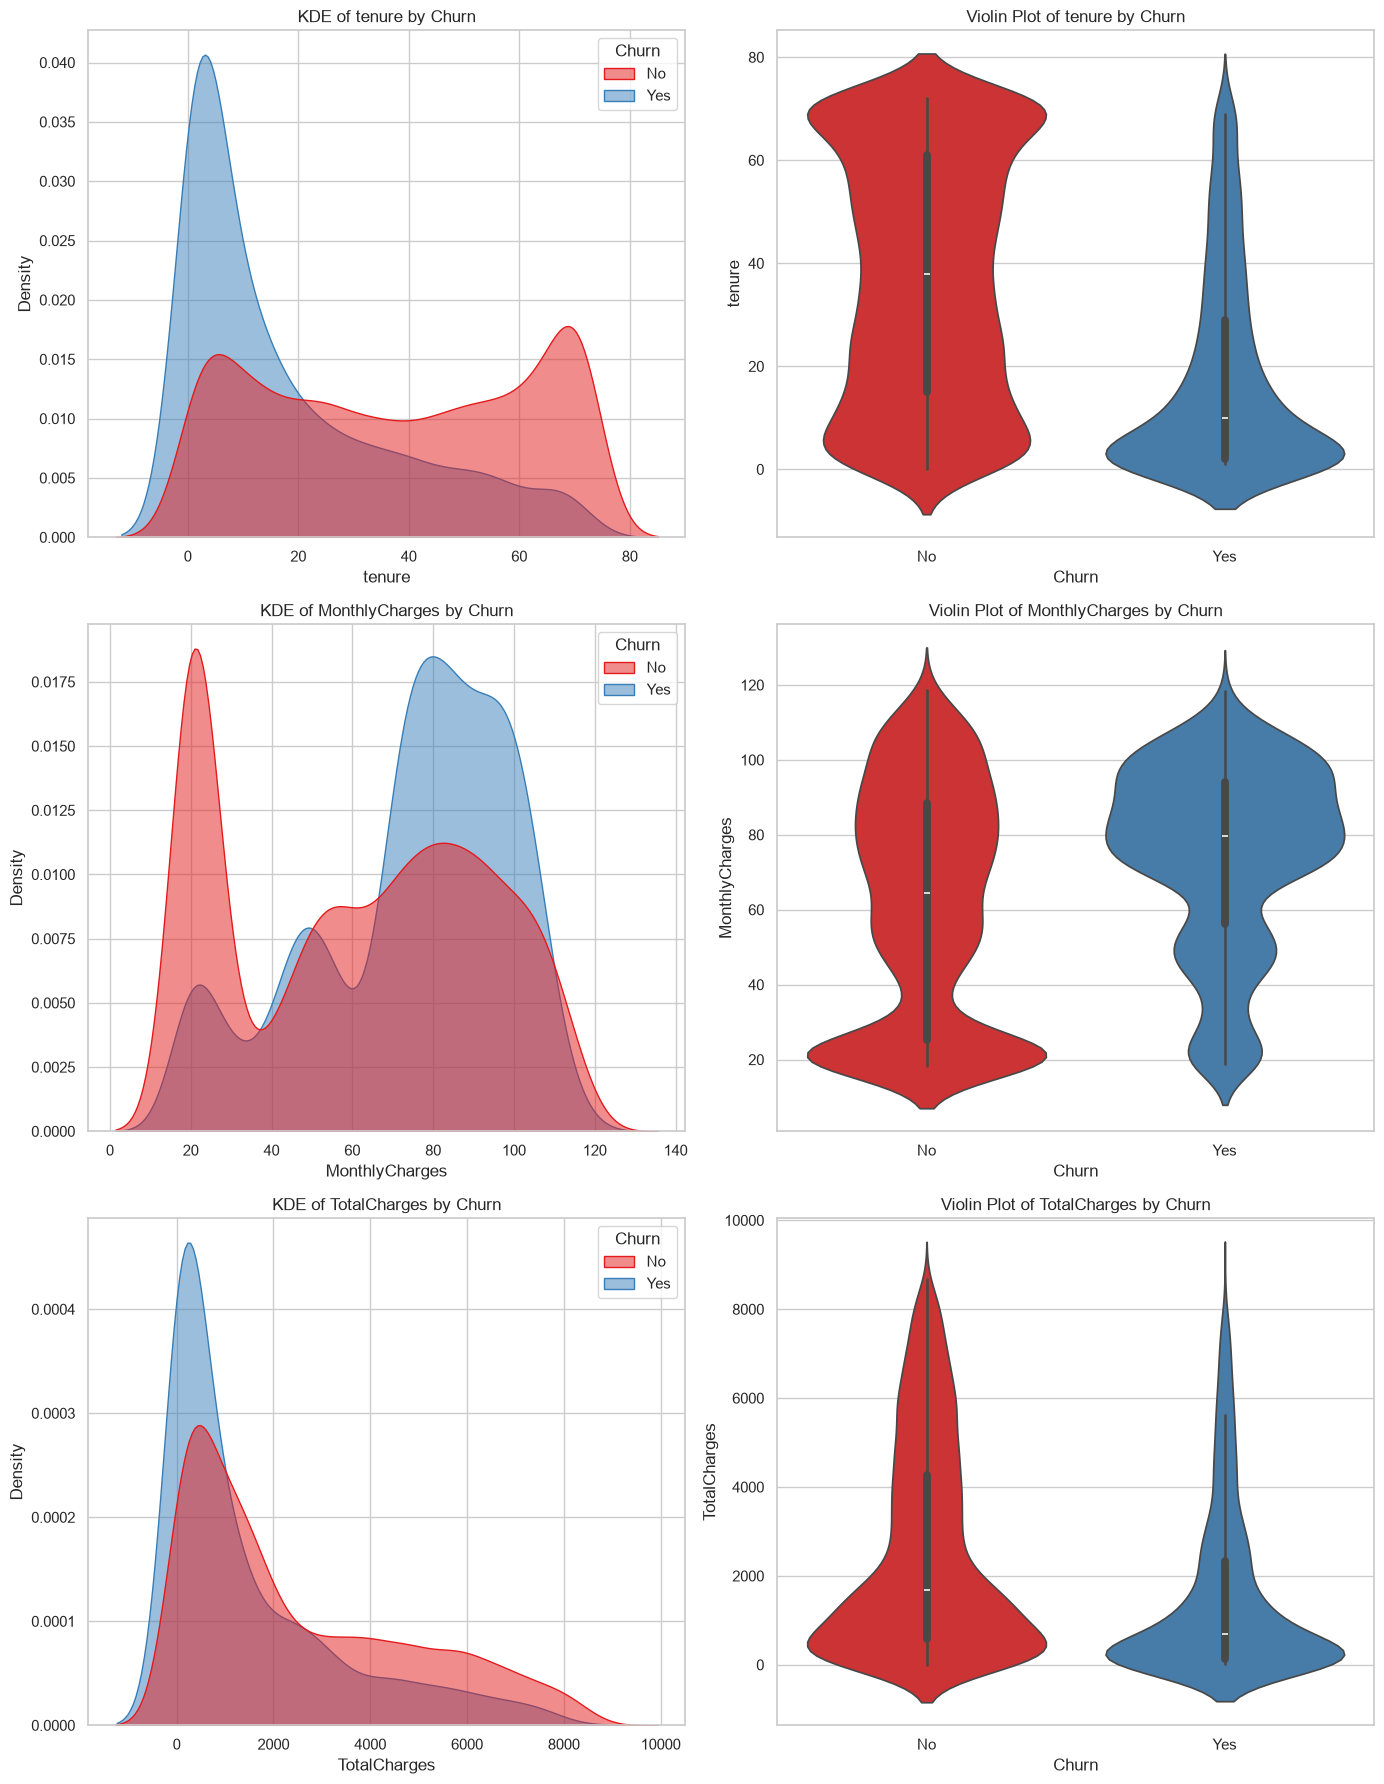

In [2]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for i, col in enumerate(num_cols):
    # KDE Plot
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette='Set1', ax=axes[i, 0], alpha=0.5)
    axes[i, 0].set_title(f'KDE of {col} by Churn')
    
    # Violin Plot
    sns.violinplot(data=df, x='Churn', y=col, palette='Set1', ax=axes[i, 1])
    axes[i, 1].set_title(f'Violin Plot of {col} by Churn')
    
plt.tight_layout()
plt.show()

### Interpretation: Numerical vs Churn
- **tenure**: There is a very strong relationship here. Customers with low tenure (especially under 10 months) have a much higher likelihood of churning. As tenure increases, churn probability drops significantly.
- **MonthlyCharges**: Customers who churn tend to have higher monthly charges. The KDE shows a large peak for churners around the $70-$100 mark, whereas non-churners have a massive peak at the lower end (~$20).
- **TotalCharges**: Since TotalCharges is tightly correlated with tenure (Total = Monthly * Tenure), churners actually tend to have *lower* total charges because they churn early before accumulating high totals.

## 2. Categorical Variables vs. Churn
Let's examine how the proportion of churn changes across different categorical groupings, specifically contract types, internet services, and payment methods.

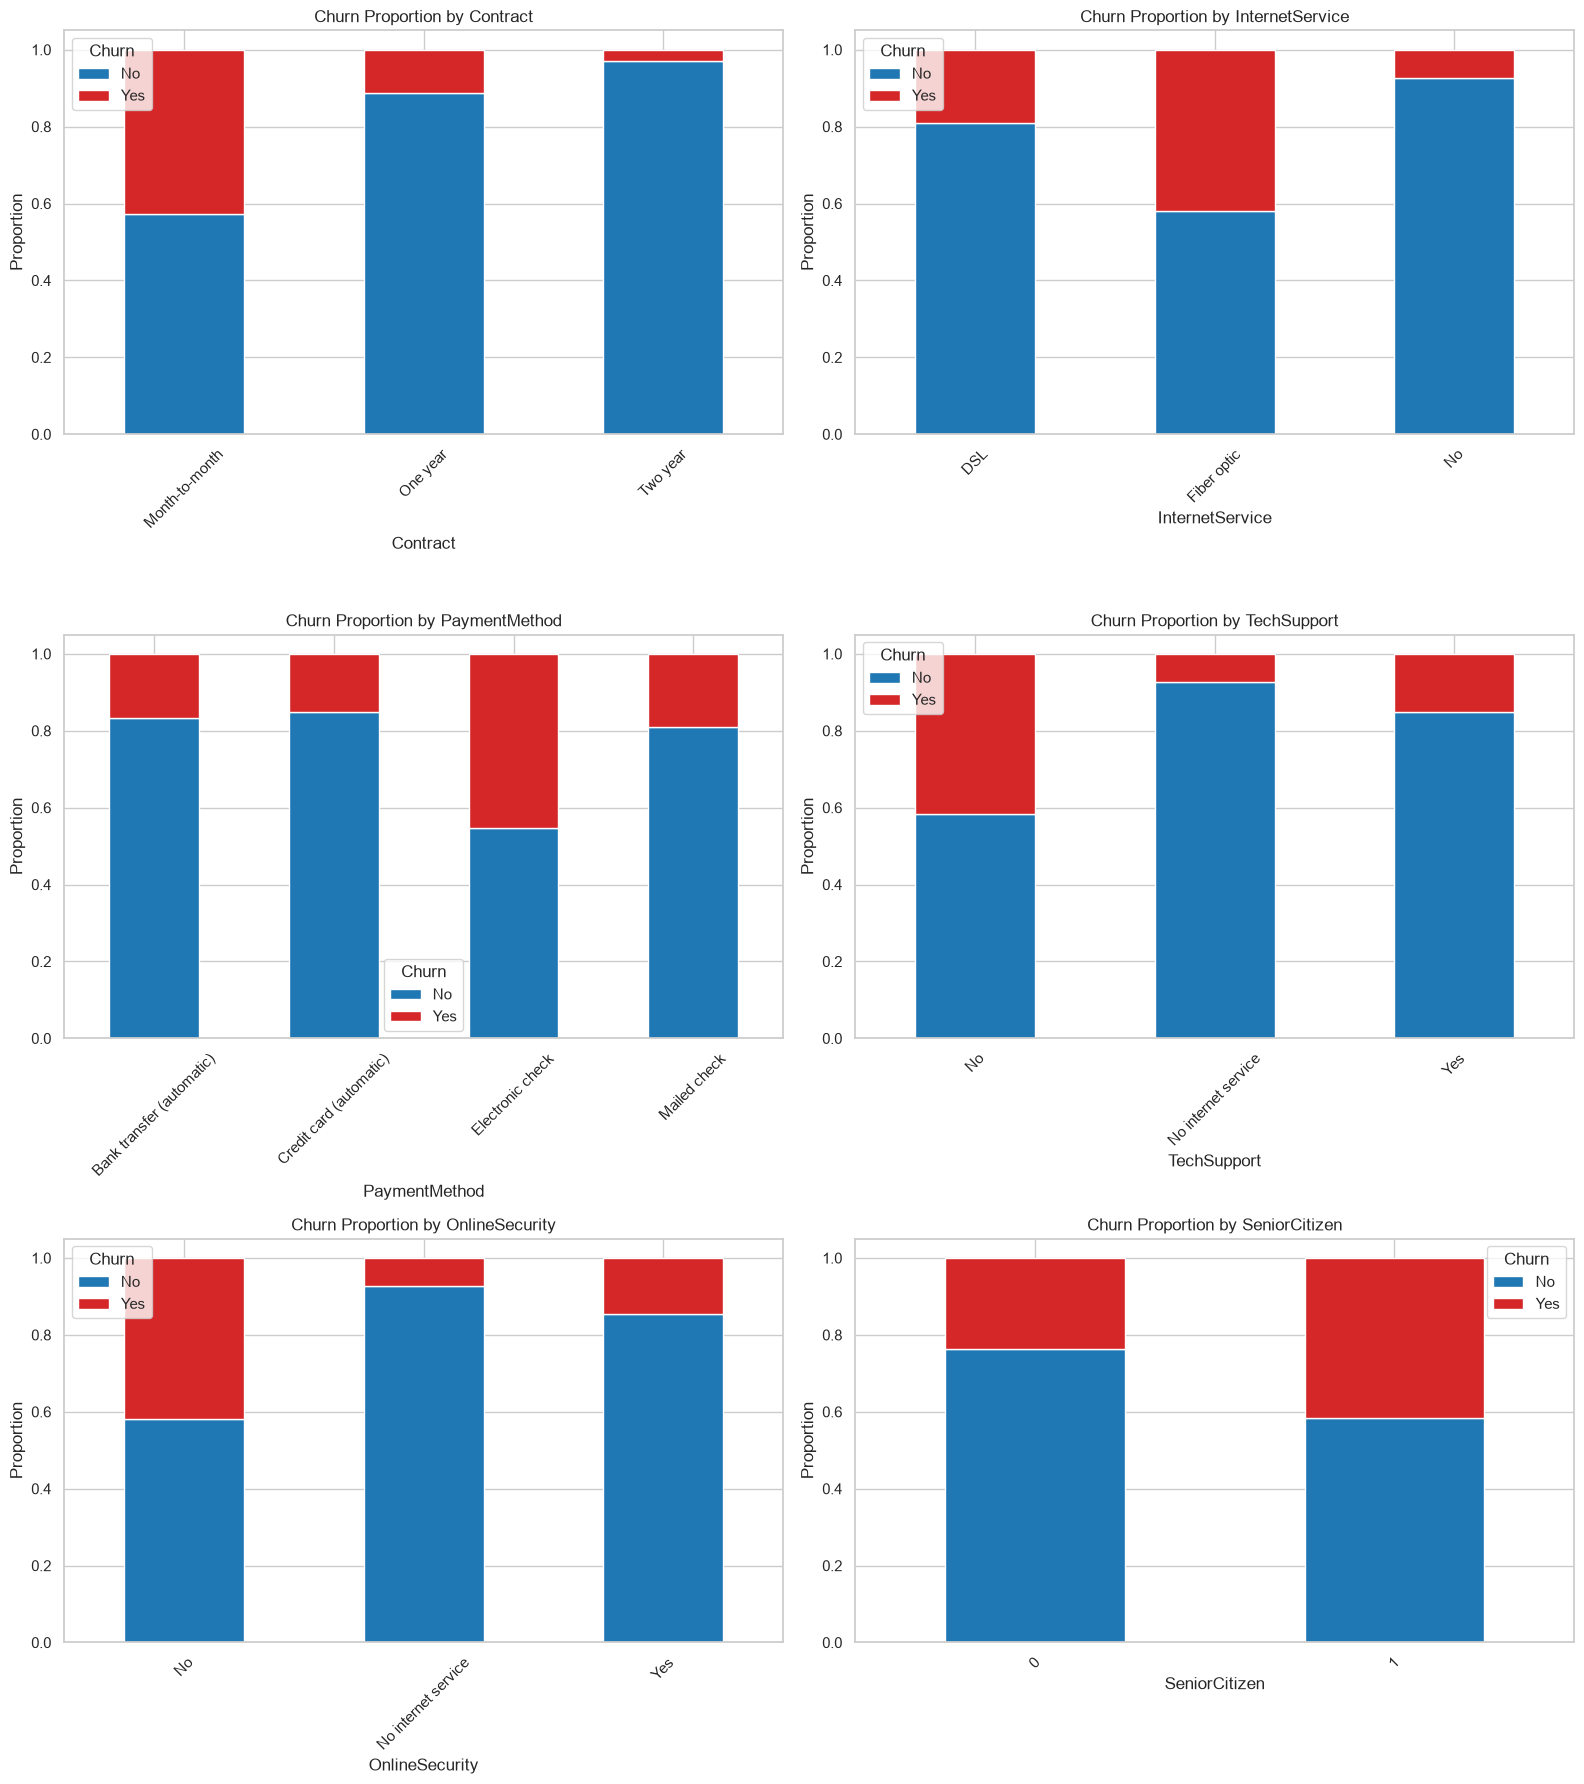

In [3]:
key_cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'SeniorCitizen']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(key_cat_cols):
    # Grouped count plot (normalize to show proportion instead of raw counts for better comparison)
    props = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    props.plot(kind='bar', stacked=True, ax=axes[i], color=['#1f77b4', '#d62728'])
    axes[i].set_title(f'Churn Proportion by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

### Interpretation: Categorical vs Churn
- **Contract**: This is one of the strongest predictors. Month-to-month contracts have a drastically higher churn rate compared to One-year and Two-year contracts.
- **Internet Service**: Customers with Fiber Optic service churn at a notably higher rate than those with DSL or no internet service. This might indicate issues with pricing, reliability, or competition in the fiber optic space.
- **Payment Method**: Electronic check users have a much higher churn rate than those using automatic payments or mailed checks.
- **Support Services**: Customers lacking Tech Support and Online Security are much more likely to churn. These services appear to act as "sticky" features that aid retention.
- **Senior Citizen**: Senior citizens churn at a higher rate than non-seniors, though they make up a smaller portion of the total base.